In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y dataset')

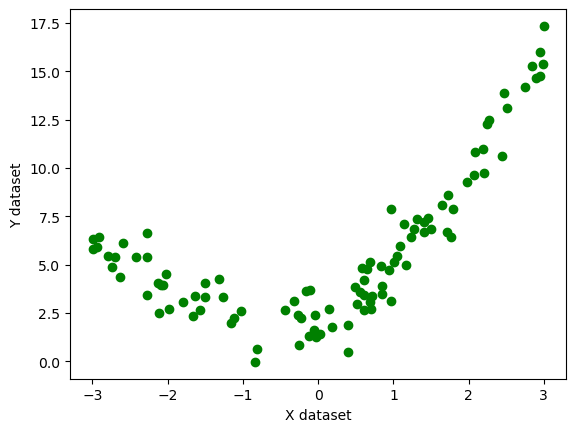

In [11]:
# Quadratic equation used as  y = 0.5 +1.5x + x^2
x =  6 * np.random.rand(100,1) -3 
y = 0.5 +x**2 +1.5*x + 2 + np.random.randn(100,1)
plt.scatter(x,y, color='g')
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state= 42)

In [14]:
## now implement simple linear regresssion
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(x_test))
print(score)

0.13766302373161932


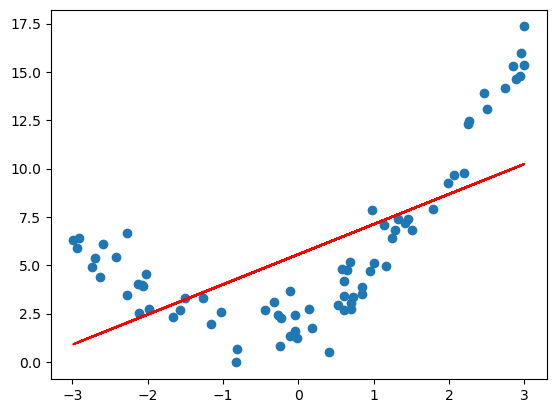

In [20]:
# visualise this model
plt.plot(x_train, regression.predict(x_train), color= 'r')
plt.scatter(x_train, y_train)


This is what the reason for the accuracy 17 %

## Polynomial Transformation

In [25]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree= 2, include_bias= True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [27]:
x_test_poly

array([[ 1.00000000e+00, -2.79745519e+00,  7.82575556e+00],
       [ 1.00000000e+00,  1.70695427e+00,  2.91369290e+00],
       [ 1.00000000e+00,  1.09203787e+00,  1.19254670e+00],
       [ 1.00000000e+00, -1.64360991e+00,  2.70145354e+00],
       [ 1.00000000e+00, -1.12461030e+00,  1.26474833e+00],
       [ 1.00000000e+00, -1.63566053e-01,  2.67538536e-02],
       [ 1.00000000e+00, -2.99552068e+00,  8.97314411e+00],
       [ 1.00000000e+00,  2.08871866e+00,  4.36274564e+00],
       [ 1.00000000e+00,  5.54133404e-01,  3.07063830e-01],
       [ 1.00000000e+00, -1.31699746e+00,  1.73448231e+00],
       [ 1.00000000e+00,  1.65182211e+00,  2.72851627e+00],
       [ 1.00000000e+00,  1.75978167e+00,  3.09683153e+00],
       [ 1.00000000e+00,  8.40590159e-01,  7.06591816e-01],
       [ 1.00000000e+00,  3.03007863e-02,  9.18137648e-04],
       [ 1.00000000e+00,  1.72162828e+00,  2.96400395e+00],
       [ 1.00000000e+00, -2.27523773e+00,  5.17670672e+00],
       [ 1.00000000e+00, -1.50947366e+00

In [28]:
x_test_poly

array([[ 1.00000000e+00, -2.79745519e+00,  7.82575556e+00],
       [ 1.00000000e+00,  1.70695427e+00,  2.91369290e+00],
       [ 1.00000000e+00,  1.09203787e+00,  1.19254670e+00],
       [ 1.00000000e+00, -1.64360991e+00,  2.70145354e+00],
       [ 1.00000000e+00, -1.12461030e+00,  1.26474833e+00],
       [ 1.00000000e+00, -1.63566053e-01,  2.67538536e-02],
       [ 1.00000000e+00, -2.99552068e+00,  8.97314411e+00],
       [ 1.00000000e+00,  2.08871866e+00,  4.36274564e+00],
       [ 1.00000000e+00,  5.54133404e-01,  3.07063830e-01],
       [ 1.00000000e+00, -1.31699746e+00,  1.73448231e+00],
       [ 1.00000000e+00,  1.65182211e+00,  2.72851627e+00],
       [ 1.00000000e+00,  1.75978167e+00,  3.09683153e+00],
       [ 1.00000000e+00,  8.40590159e-01,  7.06591816e-01],
       [ 1.00000000e+00,  3.03007863e-02,  9.18137648e-04],
       [ 1.00000000e+00,  1.72162828e+00,  2.96400395e+00],
       [ 1.00000000e+00, -2.27523773e+00,  5.17670672e+00],
       [ 1.00000000e+00, -1.50947366e+00

In [29]:
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)
score2 = r2_score(y_test, y_pred)
print(score2)

0.8274199965911345


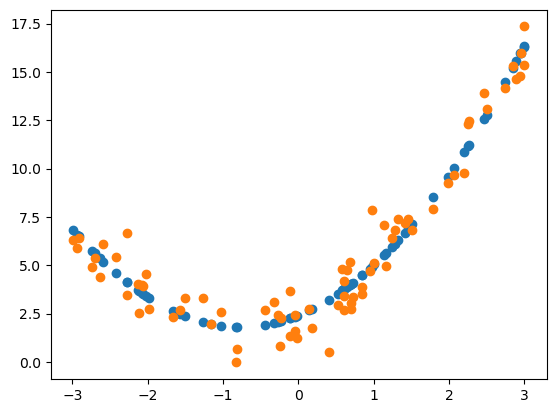

In [31]:
plt.scatter(x_train, regression.predict(x_train_poly))
plt.scatter(x_train, y_train)

In [32]:
poly = PolynomialFeatures(degree= 3, include_bias= True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [33]:
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)
score2 = r2_score(y_test, y_pred)
print(score2)

0.8269997258353355


#### Prediction of new dataset

In [34]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)

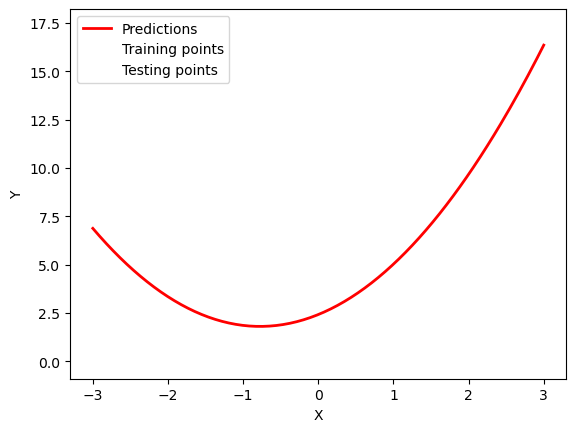

In [38]:
y_new = regression.predict(x_new_poly)
plt.plot(x_new, y_new, "r-", linewidth = 2, label = "Predictions")
plt.plot(x_train, y_train, "b ", label = "Training points")
plt.plot(x_test, y_test, "g ", label = "Testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()